# Week 2 – Data Visualization Laboratory

## Step 1: Verify the Environment

In [13]:
import sys
import pandas as pd
import matplotlib as mpl
import seaborn as sns
import altair as alt

print(sys.version)
print('pandas', pd.__version__)
print('matplotlib', mpl.__version__)
print('seaborn', sns.__version__)
print('altair', alt.__version__)

3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
pandas 2.2.3
matplotlib 3.10.0
seaborn 0.13.2
altair 5.5.0


### Checkpoint
All required libraries were imported successfully. The Python and package versions were verified and recorded.

## Step 2: Load and Recheck Palmer Penguins


In [14]:
import pandas as pd

DATA_URL = (
    'https://raw.githubusercontent.com/'
    'allisonhorst/palmerpenguins/main/'
    'inst/extdata/penguins.csv'
)

df = pd.read_csv(DATA_URL)

print(df.shape)
print(df[['species', 'body_mass_g',
          'flipper_length_mm']].isna().sum())

(344, 8)
species              0
body_mass_g          2
flipper_length_mm    2
dtype: int64


### Data Documentation

- **Provider:** Palmer Penguins dataset
- **Source:** Allison Horst – Palmer Penguins GitHub repository
- **License:** CC0
- **Retrieval Date:** September 17, 2026
- **Unit of Observation:** One sampled penguin record
- **Missing Values:** `species` = 0, `body_mass_g` = 2, `flipper_length_mm` = 2
- **Local Snapshot / Filtering:** No local snapshot or filtering was applied at this stage. The dataset was loaded directly from the source URL.

## Step 3: Experiment Question and Abstraction


### Experiment Specification

- **Audience:** Data science team reviewing measurement patterns.

- **Question:** How does flipper length relate to body mass across species?

- **Unit of Observation:** One sampled penguin record.

- **Attributes:**
  - `flipper_length_mm`: Quantitative
  - `body_mass_g`: Quantitative
  - `species`: Nominal

- **Tasks:**
  - Correlate flipper length and body mass.
  - Compare patterns across species.
  - Detect overlap and anomalies.

- **Initial Design:** Point marks with flipper length mapped to the x-position and body mass mapped to the y-position. Species is represented by hue with an optional shape encoding.

- **Limitation:** The dataset is observational; association does not establish causation.

## Step 4: Encoding Prediction


### Encoding Predictions

| Encoding Change | Expected Benefit | Expected Loss |
|---|---|---|
| **A. Body mass mapped to point area** | Point size provides a quick visual indication of relative body mass. | Area makes precise comparison of body mass more difficult. |
| **B. Species mapped only to hue** | Color provides a simple and compact way to distinguish species. | Identification depends only on color, which may reduce accessibility for some viewers. |
| **C. Species split into facets** | Separate panels reduce overlap between species and make within-species patterns clearer. | Comparing species requires more visual scanning across separate panels. |
| **D. Flipper length binned into categories** | Categories can simplify the comparison of broad flipper-length groups. | Binning removes some of the original numerical detail. |

## Step 5: Prepare One Analysis Table

A single analysis table is prepared to ensure that Matplotlib, Seaborn, and Altair use the same rows and fields. Rows with missing values in the selected variables are removed before visualization.

In [15]:
cols = ['species', 'flipper_length_mm',
        'body_mass_g']

plot_df = df[cols].dropna().copy()

print(plot_df.shape)
print(plot_df.groupby('species').size())
print(plot_df.describe(include='all').T)

(342, 3)
species
Adelie       151
Chinstrap     68
Gentoo       123
dtype: int64
                   count unique     top freq         mean         std     min  \
species              342      3  Adelie  151          NaN         NaN     NaN   
flipper_length_mm  342.0    NaN     NaN  NaN   200.915205   14.061714   172.0   
body_mass_g        342.0    NaN     NaN  NaN  4201.754386  801.954536  2700.0   

                      25%     50%     75%     max  
species               NaN     NaN     NaN     NaN  
flipper_length_mm   190.0   197.0   213.0   231.0  
body_mass_g        3550.0  4050.0  4750.0  6300.0  


### Data Preparation Note

The analysis table contains 342 complete observations and 3 selected variables. Two rows with missing values were removed from the original 344 observations.

The final analysis table contains:
- Adelie: 151 observations
- Chinstrap: 68 observations
- Gentoo: 123 observations

The same `plot_df` table will be used for all subsequent visualizations to ensure that the three libraries use the same rows and fields.

## Step 6: Matplotlib Baseline

A baseline scatter plot is created using Matplotlib to visualize the relationship between flipper length and body mass across penguin species.

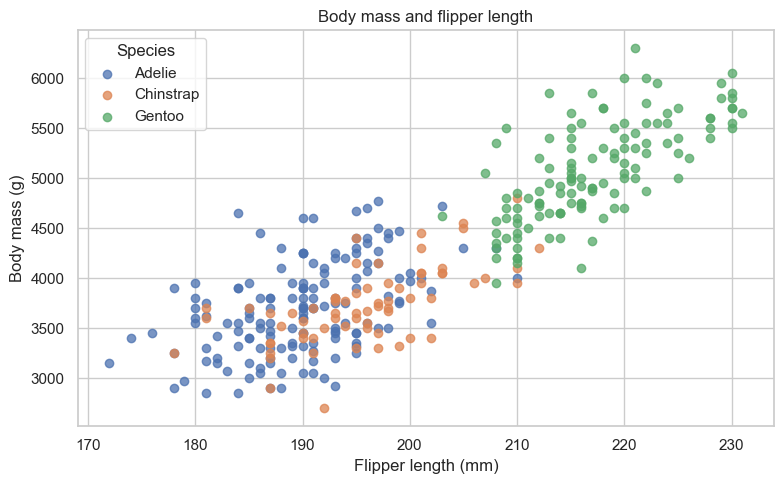

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

for species, group in plot_df.groupby('species'):
    ax.scatter(
        group['flipper_length_mm'],
        group['body_mass_g'],
        label=species,
        alpha=.75
    )

ax.set(
    title='Body mass and flipper length',
    xlabel='Flipper length (mm)',
    ylabel='Body mass (g)'
)

ax.legend(title='Species')
fig.tight_layout()

### Observation

- **Mark:** Point marks are used to represent individual penguin observations.
- **Channels:** Flipper length is mapped to x-position and body mass is mapped to y-position. Species is represented through separate plotted groups and identified in the legend.
- **Grouping:** The data is grouped by `species` using `groupby('species')`.
- **Missing-data treatment:** Rows with missing values in the selected fields were removed when `plot_df` was prepared.
- **Default choices:** Matplotlib automatically determines properties such as the group colors and point size, while transparency is explicitly set to `alpha = 0.75`.

## Step 7: Seaborn Semantic Mapping

The same analytical relationship is visualized using Seaborn. DataFrame fields are mapped directly to visual parameters, allowing species to be represented by both color and marker style.

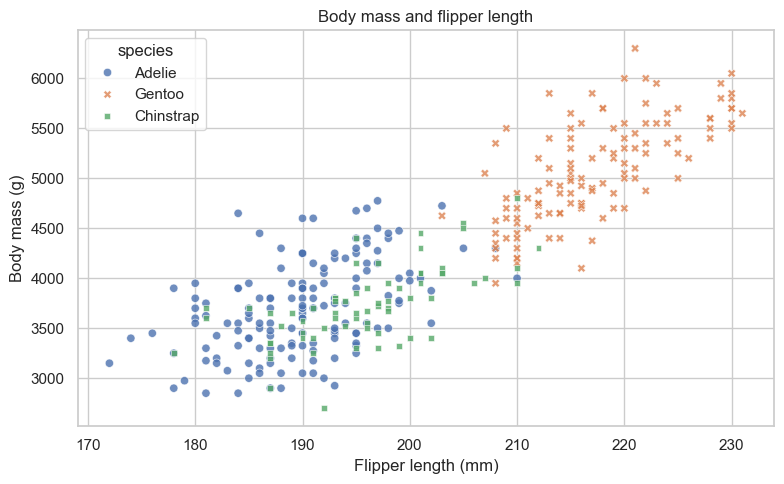

In [17]:
sns.set_theme(style='whitegrid')

fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    data=plot_df,
    x='flipper_length_mm',
    y='body_mass_g',
    hue='species',
    style='species',
    alpha=.8,
    ax=ax
)

ax.set(
    title='Body mass and flipper length',
    xlabel='Flipper length (mm)',
    ylabel='Body mass (g)'
)

fig.tight_layout()

### Comparison with Matplotlib

- Seaborn maps DataFrame fields directly to semantic parameters such as `x`, `y`, `hue`, and `style`.
- Unlike Matplotlib, manual grouping by species is not required.
- Species is encoded using both color (`hue`) and marker shape (`style`).
- The additional shape channel reduces reliance on color alone, although the marker shapes must remain clearly distinguishable.

## Step 8: Altair Declarative Specification

The same analytical relationship is visualized using Altair. Field types and visual channels are explicitly declared to make the visualization specification clear and reproducible.

In [18]:
chart = (
    alt.Chart(plot_df)
    .mark_point(filled=True, opacity=.75)
    .encode(
        x=alt.X(
            'flipper_length_mm:Q',
            title='Flipper length (mm)'
        ),
        y=alt.Y(
            'body_mass_g:Q',
            title='Body mass (g)'
        ),
        color=alt.Color(
            'species:N',
            title='Species'
        ),
        shape=alt.Shape('species:N')
    )
    .properties(
        width=600,
        height=380,
        title='Body mass and flipper length'
    )
)

chart

alt.Chart(...)

### Type Interpretation

- **`flipper_length_mm:Q`** – Quantitative field mapped to the x-position.
- **`body_mass_g:Q`** – Quantitative field mapped to the y-position.
- **`species:N`** – Nominal field mapped to color and shape.
- Explicitly declaring `Q` and `N` makes the field types and encoding assumptions clear, reviewable, and reproducible.

## Step 9: Three Libraries, One Analytical Design

The same analytical design was implemented using Matplotlib, Seaborn, and Altair. The libraries differ mainly in how data fields are mapped to visual channels and how the visualization is specified and controlled.

### Library Comparison

| Criterion | Matplotlib | Seaborn | Altair |
|---|---|---|---|
| **Data Mapping** | Manual grouping and drawing | Semantic DataFrame parameters | Declarative field-channel specification |
| **Control** | Detailed imperative control | Statistical defaults with Matplotlib access | Grammar-based configuration |
| **Type Declaration** | Implicit in code | Largely inferred from the DataFrame | Explicit types such as Q and N are encouraged |
| **Reviewability** | Trace loops and drawing commands | Inspect semantic parameters | Inspect the generated specification |
| **Week 2 Role** | Primary foundation | Primary statistical interface | Focused declarative comparison |

Matplotlib provides direct imperative control, Seaborn uses semantic DataFrame mapping, and Altair uses a declarative field-channel specification.

## Step 10: Experiment 1 – Color-Only vs Redundant Encoding

This experiment compares two versions of the same scatter plot. In the first version, species is encoded using color only. In the second version, species is encoded using both color and marker shape. The designs are compared in terms of category identification, clutter, legend complexity, and grayscale interpretation.

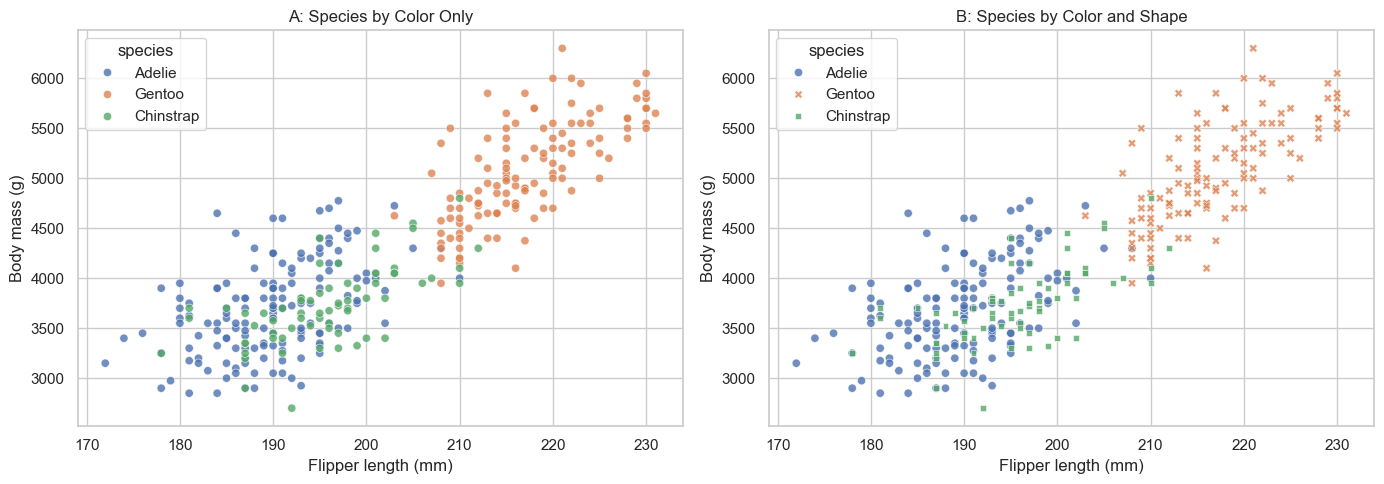

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# A: Species mapped only to hue
sns.scatterplot(
    data=plot_df,
    x='flipper_length_mm',
    y='body_mass_g',
    hue='species',
    alpha=.8,
    ax=axes[0]
)

axes[0].set(
    title='A: Species by Color Only',
    xlabel='Flipper length (mm)',
    ylabel='Body mass (g)'
)

# B: Species mapped to hue and shape
sns.scatterplot(
    data=plot_df,
    x='flipper_length_mm',
    y='body_mass_g',
    hue='species',
    style='species',
    alpha=.8,
    ax=axes[1]
)

axes[1].set(
    title='B: Species by Color and Shape',
    xlabel='Flipper length (mm)',
    ylabel='Body mass (g)'
)

plt.tight_layout()

### Experiment 1 Comparison

- **Category identification:** Color and shape make species easier to identify because two visual cues are available.
- **Clutter:** Adding shape slightly increases visual complexity, but the plot remains readable.
- **Legend complexity:** The color-and-shape legend is slightly more complex because it communicates both visual channels.
- **Grayscale interpretation:** The color-and-shape design remains easier to interpret without color because species can still be distinguished by marker shape.

**Decision:** Retain the redundant color-and-shape encoding because it improves species identification and accessibility while maintaining acceptable visual clarity.

## Step 11: Experiment 2 – Faceting

This experiment separates the penguin species into individual panels to test whether faceting reduces overlap and color dependence while preserving comparison through shared scales.

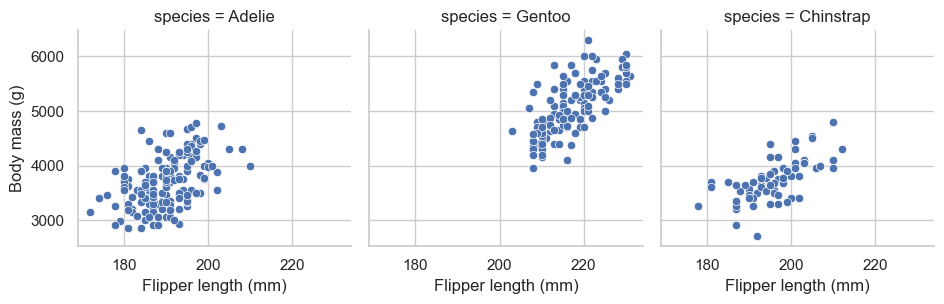

In [20]:
g = sns.relplot(
    data=plot_df,
    x='flipper_length_mm',
    y='body_mass_g',
    col='species',
    col_wrap=3,
    kind='scatter',
    height=3.2,
    facet_kws={
        'sharex': True,
        'sharey': True
    }
)

g.set_axis_labels(
    'Flipper length (mm)',
    'Body mass (g)'
)

### Experiment 2 Observation

- **Overlap:** Faceting removes overlap between species by displaying each species in a separate panel.
- **Color dependence:** Species identification no longer depends on color because each panel is labeled by species.
- **Comparison:** Shared x- and y-scales preserve meaningful comparison across the three panels.
- **Cost:** Faceting requires more eye movement between panels and makes direct point-to-point comparison more difficult.

**Decision:** Faceting is useful for reducing overlap and color dependence, but it introduces additional visual scanning across panels.

## Step 12: Experiment 3 – Area as Magnitude

This experiment maps body mass to point area instead of position to evaluate whether area is effective for representing quantitative magnitude.

Text(0.5, 1.0, 'Area encodes body mass')

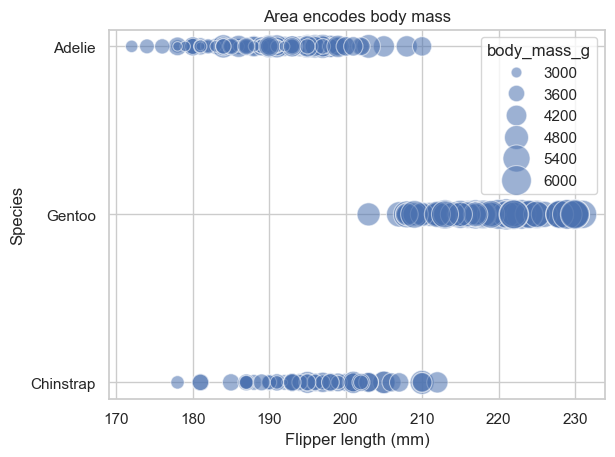

In [21]:
sns.scatterplot(
    data=plot_df,
    x='flipper_length_mm',
    y='species',
    size='body_mass_g',
    sizes=(20, 500),
    alpha=.55
)

plt.xlabel('Flipper length (mm)')
plt.ylabel('Species')
plt.title('Area encodes body mass')

### Experiment 3 Critique

- **Coarse overview:** Point area provides a quick visual impression of relative body mass; larger points generally represent heavier penguins.
- **Precise comparison:** Comparing similar point areas is difficult, so exact differences in body mass are harder to judge.
- **Overlap:** Large points can overlap and obscure nearby observations.
- **When to replace it:** If precise body-mass comparison is important, body mass should be mapped to position on a quantitative axis rather than point area.

**Decision:** Area encoding is useful for a coarse overview of body mass, but it should be replaced by positional encoding when accurate magnitude comparison is required.

## Step 13: Encoding Experiment Matrix

The three encoding experiments demonstrate that each visual encoding supports different analytical tasks and introduces different trade-offs.

| Variant | Task Supported | Main Benefit | Main Cost | Decision |
|---|---|---|---|---|
| **Hue only** | Identify species | Compact shared plot | Color dependence | Revise |
| **Hue + shape** | Identify species | Redundant identity cue | Legend complexity | Retain if readable |
| **Facets** | Compare within species | Less overlap | More scanning | Use for group detail |
| **Area for body mass** | Coarse magnitude | Compact extra variable | Low precision and overlap | Reject for exact comparison |

## Step 15: Final Redesign

Based on the encoding experiments and accessibility audit, a final scatterplot design is created to support comparison of flipper length and body mass across species while improving category identification, magnitude comparison, and readability.

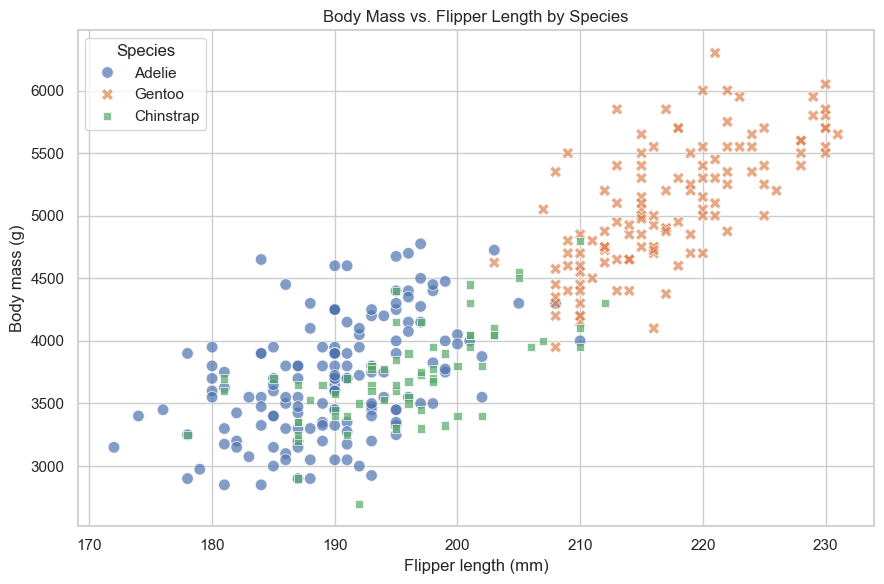

In [22]:
fig, ax = plt.subplots(figsize=(9, 6))

sns.scatterplot(
    data=plot_df,
    x='flipper_length_mm',
    y='body_mass_g',
    hue='species',
    style='species',
    alpha=.7,
    s=70,
    ax=ax
)

ax.set(
    title='Body Mass vs. Flipper Length by Species',
    xlabel='Flipper length (mm)',
    ylabel='Body mass (g)'
)

ax.legend(title='Species')
fig.tight_layout()

### Final Redesign Rationale

#### Change 1: Redundant Species Encoding
- **Task/Risk:** Reduce dependence on color for species identification.
- **Change:** Species is encoded using both color and marker shape.
- **Evidence:** Experiment 1 showed that color plus shape preserves category identification even when color alone is insufficient.
- **Remaining limitation:** Using two visual channels slightly increases legend complexity.

#### Change 2: Body Mass Encoded by Position
- **Task/Risk:** Support precise comparison of body mass.
- **Change:** Body mass is mapped to the y-position instead of point area.
- **Evidence:** Experiment 3 showed that area supports only coarse magnitude judgments, while position allows more precise comparison.
- **Remaining limitation:** Some points still overlap, especially between Adelie and Chinstrap.

#### Change 3: Clear Labels and Units
- **Task/Risk:** Avoid ambiguity in variable meaning and measurement units.
- **Change:** Descriptive axis labels with units and a clear legend title are used.
- **Evidence:** The accessibility audit requires clear units and semantics.
- **Remaining limitation:** Labels provide measurement context but do not describe the full dataset context.

#### Change 4: Point Transparency
- **Task/Risk:** Reduce the effect of overlapping observations.
- **Change:** Point transparency (`alpha=.7`) is used.
- **Evidence:** Overlapping points remain partially visible instead of completely obscuring one another.
- **Remaining limitation:** Dense overlapping regions may still be difficult to inspect precisely.

## Step 16: Project Log 2 Canvas

The following project log documents the analytical question, data structure, candidate visualization design, alternative encoding, evaluation approach, and remaining risks.

### Project Log 2

| Field | Student Entry |
|---|---|
| **Focused Question** | How does flipper length relate to body mass across penguin species? |
| **Unit of Observation** | One sampled penguin record. |
| **Attributes** | `flipper_length_mm`: quantitative, measured in mm; `body_mass_g`: quantitative, measured in g; `species`: nominal category. Two missing values were identified in both `flipper_length_mm` and `body_mass_g`. |
| **Tasks** | Correlate flipper length with body mass, compare patterns across species, and identify overlap or unusual observations. |
| **Candidate Mapping** | Scatterplot with `flipper_length_mm` mapped to x-position, `body_mass_g` to y-position, and `species` mapped to both color and marker shape. |
| **Alternative Mapping** | Faceting by `species` to reduce overlap and color dependence while preserving shared x- and y-scales. |
| **Evaluation** | Compare category identification, overlap, legend complexity, grayscale interpretation, magnitude precision, and accessibility across the tested designs. |
| **Risks** | Species overlap may obscure observations; redundant encoding may increase legend complexity; the observational sample shows association but does not establish causation. |

### Project Log 2

| Field | Student Entry |
|---|---|
| **Focused Question** | How does flipper length relate to body mass across penguin species? |
| **Unit of Observation** | One sampled penguin record. |
| **Attributes** | `species`: nominal; `flipper_length_mm`: quantitative (mm); `body_mass_g`: quantitative (g). Two missing values occur in each quantitative field. |
| **Tasks** | Correlate flipper length and body mass, compare species, identify overlap, and locate unusual observations. |
| **Candidate Mapping** | Point marks; `flipper_length_mm` by x-position; `body_mass_g` by y-position; `species` by color and shape. |
| **Alternative Mapping** | Faceted scatterplots by `species` with shared x- and y-scales to reduce overlap and color dependence. |
| **Evaluation** | Compare the candidate and alternative designs for category identification, overlap, grayscale interpretation, legend burden, and label readability. |
| **Risks** | Overlap between species, increased legend complexity from redundant encoding, and possible causal misinterpretation of an observational association. |

### Project Log 2 – Peer Review

The project log was reviewed for clarity of the unit of observation, attribute semantics, tasks, visual mapping, channel precision, evaluation, and risks.

**Peer feedback:** The evaluation should include a more explicit accessibility check for distinguishing species without relying only on color.

**Revision:** The evaluation was revised to include grayscale interpretation and category identification using both color and shape.

### Save Evidence and Record Dependencies

The notebook was restarted and all cells were executed to verify reproducibility.  
Data source, package versions, design decisions, Project Log 2, and AI-use documentation were reviewed before final submission.

Final visualization outputs are saved as supporting evidence.

### AI Use Statement

Generative AI was used to support code explanation, debugging, and clarification of visualization concepts during the laboratory work. The analysis, visual outputs, and final interpretations were reviewed and verified by the student.

### Save Visualization Evidence

Create a local figures directory and save the final Matplotlib and Altair visualizations using relative paths.

In [24]:
from pathlib import Path

# Create the figures folder if it does not already exist
Path("figures").mkdir(exist_ok=True)

# Save Matplotlib figure
fig.savefig(
    "figures/week2_scatter.png",
    dpi=200,
    bbox_inches="tight"
)

# Save Altair visualization
chart.save("figures/week2_altair.html")

print("Visualization files saved successfully.")

Visualization files saved successfully.


In [25]:
from pathlib import Path

print("Current folder:")
print(Path.cwd())

print("\nSaved files:")
print(Path("figures/week2_scatter.png").resolve())
print(Path("figures/week2_altair.html").resolve())

Current folder:
C:\Users\HUAWEI

Saved files:
C:\Users\HUAWEI\figures\week2_scatter.png
C:\Users\HUAWEI\figures\week2_altair.html
